In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from simca import SIMCAModel, SIMCAClassModel

In [88]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    # r"data/Replicate_012/Replicate_012_20251119",
    # r"data/Replicate_021/Replicate_021_20251119",
    # r"data/Replicate_022/Replicate_022_20251119",
]

xvoo_none_raw_dict = {}
wavelengths_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)
    xvoo_none_vis_path = os.path.join(base_folder, "xvoo_none", "VIS")

    if not os.path.exists(xvoo_none_vis_path):
        print(f"Upozorenje: ne postoji {xvoo_none_vis_path}, preskačem...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_vis_path, "*.csv")))
    print(f"{rep_name}: {len(files)} VIS fajlova")

    spectra = []

    for i, fpath in enumerate(files):
        df = pd.read_csv(fpath)

        if i == 0:
            wavelengths_dict[rep_name] = df["x"].values
        else:
            assert np.allclose(
                wavelengths_dict[rep_name], df["x"].values
            ), f"Talasne dužine se ne poklapaju u {rep_name}"

        spectra.append(df["y"].values)

    xvoo_none_raw_dict[rep_name] = np.array(spectra)
    print(f"{rep_name} shape:", xvoo_none_raw_dict[rep_name].shape)


Replicate_011_20251119: 10 VIS fajlova
Replicate_011_20251119 shape: (10, 288)


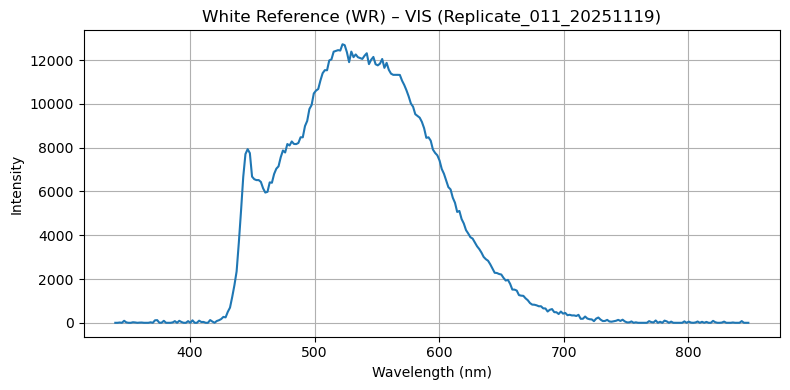

In [89]:
wr_vis_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)
    wr_path = os.path.join(base_folder, "wr", "VIS_WR.csv")

    if not os.path.exists(wr_path):
        print(f"Upozorenje: WR ne postoji za {rep_name}")
        continue

    wr_df = pd.read_csv(wr_path)
    wl_wr = wr_df["x"].values
    I_wr = wr_df["y"].values

    wr_vis_dict[rep_name] = I_wr

    # opcionalno: plot WR
    plt.figure(figsize=(8,4))
    plt.plot(wl_wr, I_wr)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(f"White Reference (WR) – VIS ({rep_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Replicate_011_20251119 normalized shape: (10, 288)


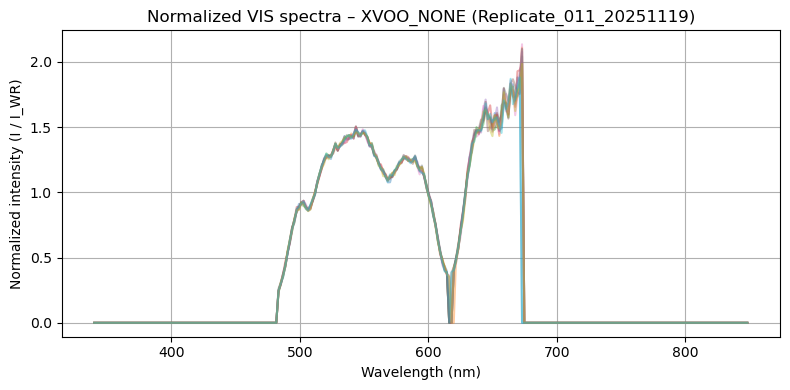

In [90]:
epsilon = 1e-10
xvoo_none_norm_dict = {}

for rep_name, spectra in xvoo_none_raw_dict.items():
    if rep_name not in wr_vis_dict:
        print(f"Preskačem {rep_name} – nema WR")
        continue

    wr = wr_vis_dict[rep_name]

    # sigurnosna provera
    assert spectra.shape[1] == wr.shape[0], \
        f"Shape mismatch VIS za {rep_name}"

    use_filter = True
    if use_filter:
        max_ = np.max(spectra)
        to_filter = spectra < 0.1*max_
    xvoo_none_norm_dict[rep_name] = spectra / (wr + epsilon)
    if use_filter:
        xvoo_none_norm_dict[rep_name][to_filter] = 0

    print(f"{rep_name} normalized shape:", xvoo_none_norm_dict[rep_name].shape)
    
for rep_name, spectra_norm in xvoo_none_norm_dict.items():
    wl = wavelengths_dict[rep_name]

    plt.figure(figsize=(8, 4))
    for i in range(len(spectra_norm)):
        plt.plot(wl, spectra_norm[i], alpha=0.4)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized intensity (I / I_WR)")
    plt.title(f"Normalized VIS spectra – XVOO_NONE ({rep_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [91]:
# Spojimo sve replicate u jednu matricu
X_list = []
for spectra_norm in xvoo_none_norm_dict.values():
    X_list.append(spectra_norm)

X = np.vstack(X_list)
y = np.array(["XVOO_NONE"] * X.shape[0])

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (10, 288)
Shape y: (10,)


Optimal number of PCA components per class: {'XVOO_NONE': 1}
SIMCA thresholds:
ODcrit: 0.2012942623448401
SDcrit: 5.62909053211915
Inside class (True = sample accepted): [ True  True  True  True  True False  True  True  True  True]


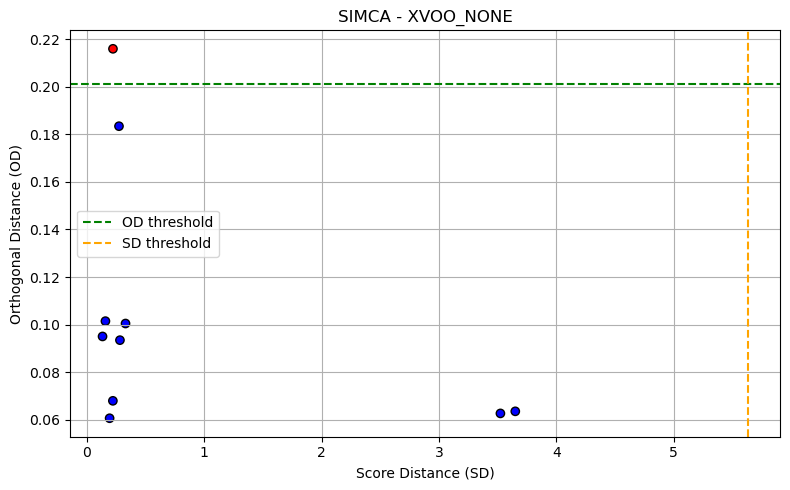

In [92]:
# X = xvoo_none_norm
# y = np.array(["XVOO_NONE"] * X.shape[0])

simca = SIMCAModel(alpha=0.05, default_n_components=None)

comp_grid = list(range(1, min(10, X.shape[1])+1))
best_components = simca.tune_num_components(
    X, y,
    comp_grid=comp_grid,
    cv=5,
    mode='rigorous',    # 'rigorous', 'compliant'
    rule='sim',         # 'sim', 'alt', 'ci', 'dd'
    od_method='percentile',    # 'percentile', 'jackson', 'box'
    sd_method='f'       # 'f', 'chi2', 'percentile'
)
print("Optimal number of PCA components per class:", best_components)

simca.fit(X, y, n_components=list(best_components.values())[0])

simca.set_thresholds_all(od_method='percentile', sd_method='f')

results = simca.predict(X, rule='sim')
res = results['XVOO_NONE']

print("SIMCA thresholds:")
print("ODcrit:", res.get('ODcrit', None))
print("SDcrit:", res.get('SDcrit', None))
print("Inside class (True = sample accepted):", res['inside'])

plt.figure(figsize=(8,5))
colors = np.where(res['inside'], 'blue', 'red')
plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - XVOO_NONE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [93]:
# plt.figure(figsize=(12,10))

# rules = {'SIMCA':'sim', 'Alt-SIMCA':'alt', 'CI-SIMCA':'ci', 'DD-SIMCA':'dd'}
# for i, (name, rule) in enumerate(rules.items(), 1):
#     res = simca.predict(X, rule=rule)['XVOO_NONE']
    
#     colors = ['blue' if flag else 'red' for flag in res['inside']]
    
#     plt.subplot(2,2,i)
#     plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
#     plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
#     plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
#     plt.title(name)
#     plt.xlabel("SD")
#     plt.ylabel("OD")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [94]:
datasets = [
    # {
    #     "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251205",
    #     "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
    #                  "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    # },
    # {
    #     "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251119",
    #     "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
    #                  "xvoo_oo50", "xvoo_oo100",
    #                  "xvoo_sfo50", "xvoo_sfo100"]
    # },
        {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    #     {
    #     "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_022\Replicate_022_20251119",
    #     "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
    #                  "xvoo_oo50", "xvoo_oo100",
    #                  "xvoo_sfo50", "xvoo_sfo100"]
    # }
]

X_list = []
y_list = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_file = os.path.join(base_folder, "wr", "VIS_WR.csv")
    wr = pd.read_csv(wr_file).iloc[:, 1].values

    print(f"\nUčitavam podatke iz: {base_folder}")
    print(f"WR shape: {wr.shape}")

    for mix in mixtures:
        vis_folder = os.path.join(base_folder, mix, "VIS")

        if not os.path.exists(vis_folder):
            print(f"Warning: folder does not exist {vis_folder}, skipping...")
            continue

        files = sorted([f for f in os.listdir(vis_folder) if f.endswith(".csv")])

        for f in files:
            df = pd.read_csv(os.path.join(vis_folder, f))
            spectrum = df.iloc[:, 1].values
            spectrum_norm = spectrum / 1.0

            X_list.append(spectrum_norm)
            y_list.append(mix)

# for i in range(xvoo_none_norm.shape[0]):
#     X_list.append(xvoo_none_norm[i])
#     y_list.append("XVOO_NONE")
    
X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

print("Unique classes:", np.unique(y_all))



Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119
WR shape: (288,)
Shape X_all_norm: (70, 288)
Shape y_all: (70,)
Unique classes: ['xvoo_lso100' 'xvoo_lso50' 'xvoo_none' 'xvoo_oo100' 'xvoo_oo50'
 'xvoo_sfo100' 'xvoo_sfo50']


In [95]:
results_mix = simca.predict(X_all_norm, rule='sim')
res_mix = results_mix['XVOO_NONE']

ODcrit = simca.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca.class_models['XVOO_NONE'].thresholds['SDcrit']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

inside = res_mix['inside']
# for i, accepted in enumerate(inside):
#     print(f"Uzorku {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

OD threshold: 0.2012942623448401
SD threshold: 5.62909053211915


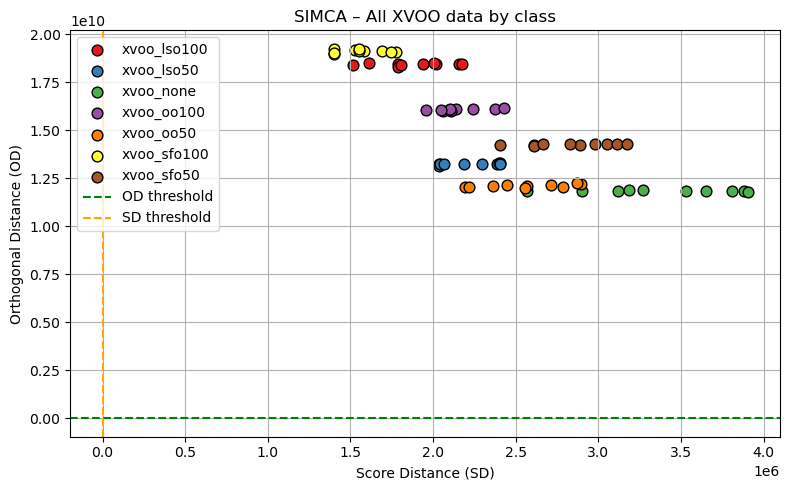

In [96]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)

contrast_colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#999999",
]

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – All XVOO data by class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
y_true = np.array([label == "XVOO_NONE" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,0,0
True MIX,0,70


In [98]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): nan%
Specificity (Rejection of MIX): 100.00%
Accuracy: 100.00%


In [99]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_lso50,False,Rejected,2.186187e+06,1.324516e+10
1,1,xvoo_lso50,False,Rejected,2.037829e+06,1.325394e+10
2,2,xvoo_lso50,False,Rejected,2.384928e+06,1.324033e+10
3,3,xvoo_lso50,False,Rejected,2.033796e+06,1.314028e+10
4,4,xvoo_lso50,False,Rejected,2.396832e+06,1.330139e+10
5,5,xvoo_lso50,False,Rejected,2.044694e+06,1.323489e+10
6,6,xvoo_lso50,False,Rejected,2.066209e+06,1.323020e+10
7,7,xvoo_lso50,False,Rejected,2.298613e+06,1.322437e+10
8,8,xvoo_lso50,False,Rejected,2.407266e+06,1.327598e+10
9,9,xvoo_lso50,False,Rejected,2.405730e+06,1.326321e+10
